# Sistem Rekomendasi Buku Menggunakan Hybrid Top-10 Recommendation

Notebook ini membangun sistem rekomendasi buku menggunakan dataset Book-Crossing. Fokus utama proyek adalah menghasilkan rekomendasi **Top-10** yang relevan untuk pengguna berdasarkan riwayat rating eksplisit.

Sistem menggunakan pendekatan hybrid yang menggabungkan beberapa sinyal rekomendasi:

1. **Bayesian Popularity**, untuk menangkap buku populer dengan koreksi jumlah rating.
2. **Content-Based Filtering**, menggunakan metadata judul, penulis, dan penerbit.
3. **Co-Like ItemKNN**, berdasarkan buku yang sering disukai bersama.
4. **Author Affinity**, berdasarkan kecenderungan pengguna menyukai penulis atau seri yang sama.
5. **User-Based Collaborative Filtering**, berdasarkan pengguna lain dengan pola buku disukai yang mirip.

Evaluasi dilakukan menggunakan skenario **Top-10 ranking** dengan split `train`, `validation`, dan `test`. Bobot hybrid dipilih berdasarkan validation set, kemudian performa akhir dilaporkan pada test set.

## 1. Business Understanding

Sistem rekomendasi buku membantu pengguna menemukan buku yang kemungkinan relevan dengan preferensi mereka. Pada dataset ini, preferensi pengguna direpresentasikan melalui rating yang diberikan pada buku.

### Problem Statement

1. Bagaimana membangun sistem rekomendasi buku yang mampu memberikan daftar Top-10 buku untuk setiap pengguna?
2. Bagaimana memanfaatkan rating eksplisit dan metadata buku untuk meningkatkan relevansi rekomendasi?
3. Bagaimana mengevaluasi kualitas rekomendasi menggunakan metrik ranking seperti `Precision@10`, `Recall@10`, `MAP@10`, dan `NDCG@10`?

### Goals

1. Membersihkan dan menyiapkan dataset Book-Crossing agar cocok untuk sistem rekomendasi.
2. Menggabungkan beberapa pendekatan rekomendasi dalam satu hybrid recommender.
3. Melakukan tuning bobot hybrid menggunakan validation set.
4. Mengukur performa akhir pada test set secara terpisah.

### Solution Approach

Proyek ini menggunakan pendekatan hybrid karena setiap metode memiliki kekuatan berbeda. Popularity membantu memberi baseline kuat, content-based menangkap kesamaan metadata, item-based dan user-based collaborative filtering menangkap pola kolektif, sedangkan author affinity menangkap pola pembaca yang menyukai penulis atau seri tertentu.

## 2. Setup dan Parameter Eksperimen

In [1]:
import math
import re
import warnings
from collections import defaultdict
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

DATA_DIR = Path(".")
RANDOM_STATE = 42
TOP_K = 10

# Optimasi warm-start. Nilai ini sengaja lebih ketat agar model punya sinyal cukup.
RELEVANT_THRESHOLD = 7
MIN_USER_EXPLICIT_RATINGS = 10
MIN_BOOK_EXPLICIT_RATINGS = 10
EVAL_USER_SAMPLE = 250
CANDIDATE_POOL = 400
CO_LIKE_NEIGHBORS = 100
USER_CF_NEIGHBORS = 80

rng = np.random.default_rng(RANDOM_STATE)

## 3. Data Understanding

Dataset terdiri dari tiga file utama:

- `Books.csv`: metadata buku, seperti ISBN, judul, penulis, tahun publikasi, penerbit, dan URL gambar.
- `Ratings.csv`: rating pengguna terhadap buku.
- `Users.csv`: informasi pengguna, seperti lokasi dan usia.

Pada proyek ini, file utama yang digunakan untuk modeling adalah `Books.csv` dan `Ratings.csv`. Rating `1-10` dipakai sebagai rating eksplisit, sedangkan rating `0` dianggap sebagai interaksi implisit dan tidak dipakai sebagai nilai rating eksplisit.

In [2]:
books_raw = pd.read_csv(DATA_DIR / "Books.csv", low_memory=False)
ratings_raw = pd.read_csv(DATA_DIR / "Ratings.csv")

print("Books:", books_raw.shape)
print("Ratings:", ratings_raw.shape)
display(books_raw.head())
display(ratings_raw.head())

Books: (271360, 8)
Ratings: (1149780, 3)


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0195153448.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0195153448.01.LZZZZZZZ.jpg
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0002005018.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0002005018.01.LZZZZZZZ.jpg
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0060973129.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0060973129.01.LZZZZZZZ.jpg
3,0374157065,Flu: The Story of the Great Influenza Pandemic of 1918 and the Search for the Virus That Caused It,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0374157065.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0374157065.01.LZZZZZZZ.jpg
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0393045218.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0393045218.01.LZZZZZZZ.jpg


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [3]:
users_raw = pd.read_csv(DATA_DIR / "Users.csv")

dataset_audit = pd.DataFrame({
    "dataset": ["Books", "Ratings", "Users"],
    "rows": [len(books_raw), len(ratings_raw), len(users_raw)],
    "columns": [books_raw.shape[1], ratings_raw.shape[1], users_raw.shape[1]],
    "duplicate_rows": [
        books_raw.duplicated().sum(),
        ratings_raw.duplicated().sum(),
        users_raw.duplicated().sum(),
    ],
})
display(dataset_audit)

print("Missing values - Books")
display(books_raw.isna().sum().to_frame("missing"))

print("Missing values - Ratings")
display(ratings_raw.isna().sum().to_frame("missing"))

print("Missing values - Users")
display(users_raw.isna().sum().to_frame("missing"))

,dataset,rows,columns,duplicate_rows
0,Books,271360,8,0
1,Ratings,1149780,3,0
2,Users,278858,3,0


Missing values - Books


,missing
ISBN,0
Book-Title,0
Book-Author,2
Year-Of-Publication,0
Publisher,2
Image-URL-S,0
Image-URL-M,0
Image-URL-L,3


Missing values - Ratings


,missing
User-ID,0
ISBN,0
Book-Rating,0


Missing values - Users


,missing
User-ID,0
Location,0
Age,110762


Rating eksplisit 1-10: 433,671
Interaksi implisit 0 : 716,109
Proporsi implisit    : 62.28%


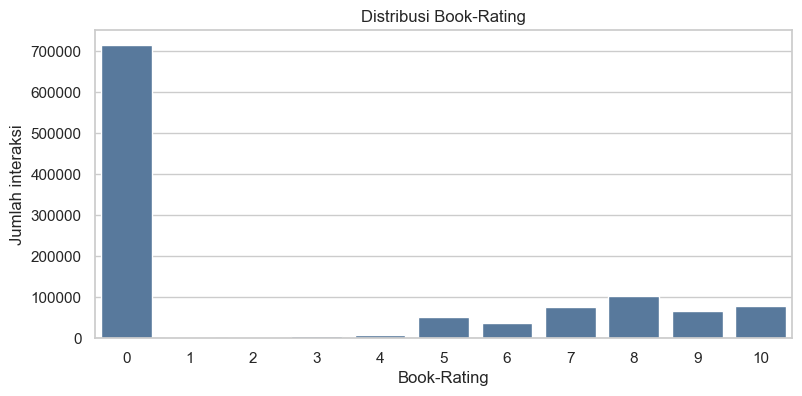

In [4]:
rating_distribution = ratings_raw["Book-Rating"].value_counts().sort_index()
explicit_count = int((ratings_raw["Book-Rating"] > 0).sum())
implicit_count = int((ratings_raw["Book-Rating"] == 0).sum())

print(f"Rating eksplisit 1-10: {explicit_count:,}")
print(f"Interaksi implisit 0 : {implicit_count:,}")
print(f"Proporsi implisit    : {implicit_count / len(ratings_raw):.2%}")

plt.figure(figsize=(9, 4))
sns.barplot(x=rating_distribution.index, y=rating_distribution.values, color="#4C78A8")
plt.title("Distribusi Book-Rating")
plt.xlabel("Book-Rating")
plt.ylabel("Jumlah interaksi")
plt.show()

Rating `0` tidak merepresentasikan rating buruk. Nilai tersebut menunjukkan adanya interaksi tanpa rating eksplisit. Karena itu, model ranking utama dibangun dari rating eksplisit `1-10`, agar nilai `0` tidak salah dibaca sebagai preferensi negatif.

## 4. Data Preparation

Tahap persiapan data meliputi:

1. Memperbaiki beberapa baris metadata buku yang kolomnya bergeser.
2. Mengisi missing value pada penulis dan penerbit.
3. Menormalisasi teks judul, penulis, dan penerbit.
4. Menyatukan edisi buku dari level ISBN ke level buku kanonis menggunakan kombinasi judul dan penulis.

Penyatuan edisi penting karena satu buku dapat memiliki beberapa ISBN akibat perbedaan edisi, penerbit, atau format.

In [5]:
def normalize_text(value):
    if pd.isna(value):
        return "unknown"
    value = str(value).lower().strip()
    value = re.sub(r"&amp;", "&", value)
    value = re.sub(r"[^a-z0-9]+", " ", value)
    value = re.sub(r"\s+", " ", value).strip()
    return value or "unknown"


books = books_raw.copy()

manual_fixes = {
    "078946697X": {
        "Book-Title": "DK Readers: Creating the X-Men, How It All Began (Level 4: Proficient Readers)",
        "Book-Author": "Michael Teitelbaum",
        "Year-Of-Publication": "2000",
        "Publisher": "DK Publishing Inc",
    },
    "0789466953": {
        "Book-Title": "DK Readers: Creating the X-Men, How Comic Books Come to Life (Level 4: Proficient Readers)",
        "Book-Author": "James Buckley",
        "Year-Of-Publication": "2000",
        "Publisher": "DK Publishing Inc",
    },
    "2070426769": {
        "Book-Title": "Peuple du ciel - Suivi de Les bergers",
        "Book-Author": "Jean-Marie Gustave Le Clezio",
        "Year-Of-Publication": "2003",
        "Publisher": "Gallimard",
    },
}

for isbn, fixes in manual_fixes.items():
    mask = books["ISBN"].eq(isbn)
    for col, value in fixes.items():
        books.loc[mask, col] = value

books["Book-Author"] = books["Book-Author"].fillna("Unknown")
books["Publisher"] = books["Publisher"].fillna("Unknown").str.replace("&amp;", "&", regex=False)
books["title_key"] = books["Book-Title"].map(normalize_text)
books["author_key"] = books["Book-Author"].map(normalize_text)
books["publisher_key"] = books["Publisher"].map(normalize_text)
books["book_key"] = books["title_key"] + " | " + books["author_key"]
books["book_id"] = pd.factorize(books["book_key"])[0].astype("int32")

catalog = (
    books.groupby("book_id")
    .agg(
        Book_Title=("Book-Title", "first"),
        Book_Author=("Book-Author", "first"),
        Publisher=("Publisher", "first"),
        title_key=("title_key", "first"),
        author_key=("author_key", "first"),
        publisher_key=("publisher_key", "first"),
        n_isbn=("ISBN", "nunique"),
    )
    .reset_index()
)

print("ISBN unik:", books["ISBN"].nunique())
print("Book kanonis:", catalog["book_id"].nunique())
display(catalog.sort_values("n_isbn", ascending=False).head(10))

ISBN unik: 271360
Book kanonis: 245633


,book_id,Book_Title,Book_Author,Publisher,title_key,author_key,publisher_key,n_isbn
4184,4184,Little Women,Louisa May Alcott,Octopus Publising Group Plc,little women,louisa may alcott,octopus publising group plc,23
975,975,Wuthering Heights,EMILY BRONTE,Bantam,wuthering heights,emily bronte,bantam,22
2291,2291,Adventures of Huckleberry Finn,Mark Twain,Globe Fearon,adventures of huckleberry finn,mark twain,globe fearon,20
41,41,Pride and Prejudice,Jane Austen,Bantam,pride and prejudice,jane austen,bantam,19
3643,3643,The Secret Garden,Frances Hodgson Burnett,Tor Books,the secret garden,frances hodgson burnett,tor books,17
2874,2874,Dracula,Bram Stoker,Dorset Press,dracula,bram stoker,dorset press,17
3227,3227,Jane Eyre,Charlotte Bronte,New Amer Library Classics,jane eyre,charlotte bronte,new amer library classics,16
7313,7313,Great Expectations,Charles Dickens,Aladdin,great expectations,charles dickens,aladdin,16
1463,1463,Emma,Jane Austen,New Amer Library Classics,emma,jane austen,new amer library classics,16
14753,14753,Black Beauty,Anna Sewell,Yearling Books,black beauty,anna sewell,yearling books,14


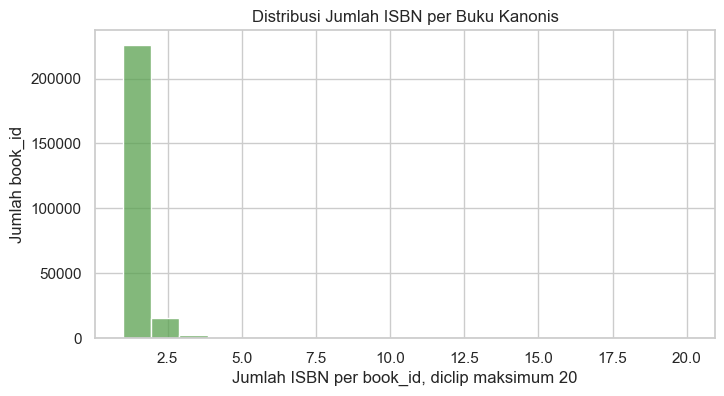

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(catalog["n_isbn"].clip(upper=20), bins=20, color="#59A14F")
plt.title("Distribusi Jumlah ISBN per Buku Kanonis")
plt.xlabel("Jumlah ISBN per book_id, diclip maksimum 20")
plt.ylabel("Jumlah book_id")
plt.show()

## 5. Menyiapkan Data Interaksi

Dataset rating digabungkan dengan metadata buku agar setiap ISBN dapat dipetakan ke `book_id`. Jika seorang pengguna memberi rating pada beberapa ISBN dari buku kanonis yang sama, rating maksimum dipakai sebagai sinyal preferensi terkuat.

Filtering warm-start digunakan agar model collaborative filtering memiliki cukup sinyal. Pengguna dan buku yang terlalu sedikit interaksinya tidak digunakan pada tahap modeling utama.

In [7]:
isbn_to_book_id = books[["ISBN", "book_id"]].drop_duplicates()

explicit_events = (
    ratings_raw[ratings_raw["Book-Rating"].between(1, 10)]
    .merge(isbn_to_book_id, on="ISBN", how="inner")
    .groupby(["User-ID", "book_id"], as_index=False)
    .agg(rating=("Book-Rating", "max"))
)

def filter_interactions(events, min_user_ratings, min_book_ratings):
    filtered = events.copy()
    while True:
        before = len(filtered)
        user_counts = filtered["User-ID"].value_counts()
        book_counts = filtered["book_id"].value_counts()
        filtered = filtered[
            filtered["User-ID"].isin(user_counts[user_counts >= min_user_ratings].index)
            & filtered["book_id"].isin(book_counts[book_counts >= min_book_ratings].index)
        ].copy()
        if len(filtered) == before:
            return filtered

warm_events = filter_interactions(
    explicit_events,
    MIN_USER_EXPLICIT_RATINGS,
    MIN_BOOK_EXPLICIT_RATINGS,
)

print("Explicit events:", explicit_events.shape)
print("Warm events    :", warm_events.shape)
print("Warm users     :", warm_events["User-ID"].nunique())
print("Warm books     :", warm_events["book_id"].nunique())

Explicit events: (382868, 3)
Warm events    : (55611, 3)
Warm users     : 2255
Warm books     : 2437


Matrix density warm explicit: 1.01195%


,rating_per_user
count,2255.000000
mean,24.661197
std,33.096342
min,10.000000
50%,17.000000
75%,27.000000
90%,45.600000
95%,61.000000
99%,115.460000
max,1198.000000


,rating_per_book
count,2437.000000
mean,22.819450
std,19.898579
min,10.000000
50%,16.000000
75%,25.000000
90%,44.000000
95%,60.000000
99%,107.640000
max,247.000000


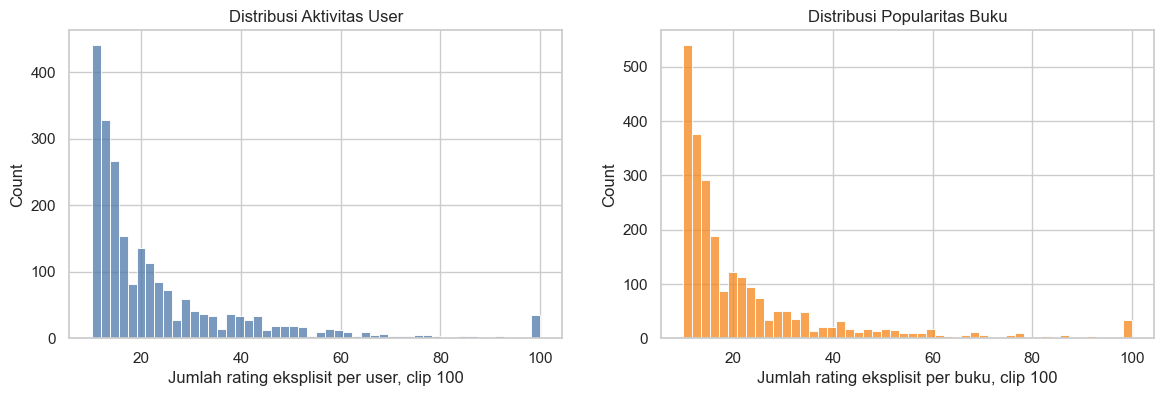

In [8]:
user_activity = warm_events.groupby("User-ID").size()
book_activity = warm_events.groupby("book_id").size()
density = len(warm_events) / (warm_events["User-ID"].nunique() * warm_events["book_id"].nunique())

print(f"Matrix density warm explicit: {density:.5%}")
display(user_activity.describe(percentiles=[.5, .75, .9, .95, .99]).to_frame("rating_per_user"))
display(book_activity.describe(percentiles=[.5, .75, .9, .95, .99]).to_frame("rating_per_book"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(user_activity.clip(upper=100), bins=50, ax=axes[0], color="#4C78A8")
axes[0].set_title("Distribusi Aktivitas User")
axes[0].set_xlabel("Jumlah rating eksplisit per user, clip 100")

sns.histplot(book_activity.clip(upper=100), bins=50, ax=axes[1], color="#F58518")
axes[1].set_title("Distribusi Popularitas Buku")
axes[1].set_xlabel("Jumlah rating eksplisit per buku, clip 100")
plt.show()

## 6. Train, Validation, dan Test Split

Evaluasi menggunakan skenario leave-two-out untuk pengguna yang memiliki minimal dua buku relevan. Satu item relevan disimpan sebagai validation item dan satu item relevan lain disimpan sebagai test item.

Validation set digunakan untuk memilih bobot hybrid terbaik. Test set hanya digunakan untuk pelaporan performa akhir.

In [9]:
def train_val_test_split(events, relevant_threshold=7, random_state=42):
    train_idx = set(events.index)
    val_rows = []
    test_rows = []

    for user_id, group in events.groupby("User-ID"):
        relevant = group[group["rating"] >= relevant_threshold]
        if len(group) < 5 or len(relevant) < 2:
            continue

        picked = relevant.sample(n=2, random_state=random_state)
        val_rows.append(picked.iloc[[0]])
        test_rows.append(picked.iloc[[1]])
        train_idx -= set(picked.index)

    val = pd.concat(val_rows, ignore_index=False)
    test = pd.concat(test_rows, ignore_index=False)
    train = events.loc[sorted(train_idx)].copy()

    eligible_users = set(val["User-ID"]) & set(test["User-ID"])
    train = train[train["User-ID"].isin(eligible_users)].copy()
    val = val[val["User-ID"].isin(eligible_users)].copy()
    test = test[test["User-ID"].isin(eligible_users)].copy()
    return train, val, test


train_events, val_events, test_events = train_val_test_split(
    warm_events,
    relevant_threshold=RELEVANT_THRESHOLD,
    random_state=RANDOM_STATE,
)

train_seen = train_events.groupby("User-ID")["book_id"].apply(set).to_dict()
print("Train:", train_events.shape)
print("Validation:", val_events.shape)
print("Test:", test_events.shape)
print("Eligible users:", test_events["User-ID"].nunique())

Train: (50558, 3)
Validation: (2239, 3)
Test: (2239, 3)
Eligible users: 2239


## 7. Modeling

Model hybrid dibangun dari lima sinyal rekomendasi. Masing-masing sinyal menghasilkan skor kandidat buku, kemudian skor dinormalisasi dan digabungkan menggunakan bobot yang dipilih melalui grid search pada validation set.

In [10]:
def minmax_dict(scores):
    if not scores:
        return {}
    values = np.array(list(scores.values()), dtype=float)
    lo, hi = np.nanmin(values), np.nanmax(values)
    if hi == lo:
        return {key: 1.0 for key in scores}
    return {key: (value - lo) / (hi - lo) for key, value in scores.items()}


def attach_catalog(recs):
    return recs.merge(catalog, on="book_id", how="left")

### 7.1 Bayesian Popularity

In [11]:
# 1. Bayesian popularity
popularity_stats = (
    train_events.groupby("book_id")
    .agg(rating_count=("rating", "size"), avg_rating=("rating", "mean"))
    .reset_index()
)
global_mean = train_events["rating"].mean()
m = popularity_stats["rating_count"].quantile(0.75)
popularity_stats["popularity_score"] = (
    (popularity_stats["rating_count"] / (popularity_stats["rating_count"] + m)) * popularity_stats["avg_rating"]
    + (m / (popularity_stats["rating_count"] + m)) * global_mean
)

popularity_rank = popularity_stats.sort_values(
    ["popularity_score", "rating_count"], ascending=False
)["book_id"].tolist()
popularity_score = dict(zip(popularity_stats["book_id"], popularity_stats["popularity_score"]))

### 7.2 Content-Based Filtering

In [12]:
# 2. Content-based profile
model_book_ids = sorted(train_events["book_id"].unique())
catalog_model = catalog[catalog["book_id"].isin(model_book_ids)].reset_index(drop=True).copy()
catalog_model["content_text"] = (
    catalog_model["title_key"].fillna("")
    + " author_" + catalog_model["author_key"].fillna("").str.replace(" ", "_")
    + " publisher_" + catalog_model["publisher_key"].fillna("").str.replace(" ", "_")
)

tfidf = TfidfVectorizer(
    min_df=2,
    max_features=20000,
    ngram_range=(1, 2),
    stop_words="english",
)
content_matrix = tfidf.fit_transform(catalog_model["content_text"])
book_id_to_content_idx = pd.Series(catalog_model.index.values, index=catalog_model["book_id"]).to_dict()

print("Content matrix:", content_matrix.shape)

Content matrix: (2437, 2598)


### 7.3 Co-Like ItemKNN dan User-Based Collaborative Filtering

In [13]:
# 3. Co-like item KNN berbasis buku yang benar-benar disukai
liked_train = train_events[train_events["rating"] >= RELEVANT_THRESHOLD].copy()
user_codes, user_uniques = pd.factorize(liked_train["User-ID"])
item_codes, item_uniques = pd.factorize(liked_train["book_id"])

liked_item_user = csr_matrix(
    (np.ones(len(liked_train)), (item_codes, user_codes)),
    shape=(len(item_uniques), len(user_uniques)),
)

book_id_to_liked_code = {book_id: code for code, book_id in enumerate(item_uniques)}
liked_code_to_book_id = {code: book_id for code, book_id in enumerate(item_uniques)}

co_like_model = NearestNeighbors(metric="cosine", algorithm="brute")
co_like_model.fit(liked_item_user)

co_like_neighbors = {}
for book_id, code_idx in book_id_to_liked_code.items():
    n_neighbors = min(CO_LIKE_NEIGHBORS + 1, liked_item_user.shape[0])
    distances, indices = co_like_model.kneighbors(liked_item_user[code_idx], n_neighbors=n_neighbors)
    neighbors = []
    for distance, neighbor_idx in zip(distances.ravel(), indices.ravel()):
        neighbor_book_id = liked_code_to_book_id[neighbor_idx]
        if neighbor_book_id == book_id:
            continue
        similarity = 1 - distance
        if similarity > 0:
            neighbors.append((neighbor_book_id, similarity))
    co_like_neighbors[book_id] = neighbors

liked_history = liked_train.groupby("User-ID")[["book_id", "rating"]].apply(
    lambda df: list(df.itertuples(index=False, name=None))
).to_dict()

print("Liked item-user matrix:", liked_item_user.shape)

# User-based CF memakai transpose matrix liked item-user.
# Model ini mencari user yang pola buku disukainya mirip, lalu mengambil buku yang mereka sukai.
liked_user_item = liked_item_user.T.tocsr()
user_cf_model = NearestNeighbors(metric="cosine", algorithm="brute")
user_cf_model.fit(liked_user_item)
user_id_to_liked_code = {user_id: code for code, user_id in enumerate(user_uniques)}
liked_code_to_user_id = {code: user_id for code, user_id in enumerate(user_uniques)}

print("Liked user-item matrix:", liked_user_item.shape)

Liked item-user matrix: (2437, 2231)
Liked user-item matrix: (2231, 2437)


### 7.4 Author Affinity

In [14]:
# 4. Author affinity
book_to_author = dict(zip(catalog["book_id"], catalog["author_key"]))
author_to_books = catalog_model.groupby("author_key")["book_id"].apply(list).to_dict()

### 7.5 Fungsi Scoring dan Hybrid Recommendation

In [15]:
def score_popularity(user_id, pool=CANDIDATE_POOL):
    seen = train_seen.get(user_id, set())
    candidates = [book_id for book_id in popularity_rank if book_id not in seen][:pool]
    return {book_id: popularity_score.get(book_id, 0.0) for book_id in candidates}


def score_content(user_id, pool=CANDIDATE_POOL):
    history = train_events[
        (train_events["User-ID"].eq(user_id))
        & (train_events["rating"] >= RELEVANT_THRESHOLD)
        & (train_events["book_id"].isin(book_id_to_content_idx))
    ].copy()

    if history.empty:
        return score_popularity(user_id, pool=pool)

    idx = [book_id_to_content_idx[book_id] for book_id in history["book_id"]]
    weights = (history["rating"].to_numpy() - RELEVANT_THRESHOLD + 1).clip(min=1)
    profile = csr_matrix(content_matrix[idx].multiply(weights[:, None]).sum(axis=0))
    scores = (content_matrix @ profile.T).toarray().ravel()

    for book_id in train_seen.get(user_id, set()):
        if book_id in book_id_to_content_idx:
            scores[book_id_to_content_idx[book_id]] = -np.inf

    top_idx = np.argpartition(scores, -min(pool, len(scores)))[-min(pool, len(scores)):]
    top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
    return {
        int(catalog_model["book_id"].iloc[i]): float(scores[i])
        for i in top_idx
        if np.isfinite(scores[i])
    }


def score_colike(user_id, pool=CANDIDATE_POOL):
    seen = train_seen.get(user_id, set())
    scores = defaultdict(float)

    for book_id, rating in sorted(liked_history.get(user_id, []), key=lambda x: x[1], reverse=True)[:25]:
        for neighbor_book_id, similarity in co_like_neighbors.get(book_id, []):
            if neighbor_book_id not in seen:
                scores[neighbor_book_id] += similarity * max(rating - RELEVANT_THRESHOLD + 1, 1)

    if not scores:
        return score_popularity(user_id, pool=pool)

    return dict(sorted(scores.items(), key=lambda x: x[1], reverse=True)[:pool])


def score_author(user_id, pool=CANDIDATE_POOL):
    seen = train_seen.get(user_id, set())
    scores = defaultdict(float)

    for book_id, rating in liked_history.get(user_id, []):
        author = book_to_author.get(book_id)
        if not author or author == "unknown":
            continue
        for candidate_book_id in author_to_books.get(author, []):
            if candidate_book_id not in seen:
                scores[candidate_book_id] += max(rating - RELEVANT_THRESHOLD + 1, 1)
                scores[candidate_book_id] += 0.05 * popularity_score.get(candidate_book_id, 0.0)

    return dict(sorted(scores.items(), key=lambda x: x[1], reverse=True)[:pool])


def score_usercf(user_id, pool=CANDIDATE_POOL):
    if user_id not in user_id_to_liked_code:
        return {}

    seen = train_seen.get(user_id, set())
    user_code = user_id_to_liked_code[user_id]
    n_neighbors = min(USER_CF_NEIGHBORS + 1, liked_user_item.shape[0])
    distances, indices = user_cf_model.kneighbors(liked_user_item[user_code], n_neighbors=n_neighbors)
    scores = defaultdict(float)

    for distance, neighbor_code in zip(distances.ravel(), indices.ravel()):
        neighbor_user_id = liked_code_to_user_id[neighbor_code]
        if neighbor_user_id == user_id:
            continue
        similarity = 1 - distance
        if similarity <= 0:
            continue

        for book_id, rating in liked_history.get(neighbor_user_id, []):
            if book_id not in seen:
                scores[book_id] += similarity * max(rating - RELEVANT_THRESHOLD + 1, 1)

    return dict(sorted(scores.items(), key=lambda x: x[1], reverse=True)[:pool])


score_cache = {}


def get_user_scores(user_id):
    if user_id not in score_cache:
        score_cache[user_id] = {
            "popularity": minmax_dict(score_popularity(user_id)),
            "content": minmax_dict(score_content(user_id)),
            "colike": minmax_dict(score_colike(user_id)),
            "author": minmax_dict(score_author(user_id)),
            "usercf": minmax_dict(score_usercf(user_id)),
        }
    return score_cache[user_id]


def recommend_weighted(user_id, weights, n=TOP_K):
    user_scores = get_user_scores(user_id)
    combined = defaultdict(float)

    for model_name, weight in weights.items():
        for book_id, score in user_scores[model_name].items():
            combined[book_id] += weight * score

    ranked = sorted(combined.items(), key=lambda x: x[1], reverse=True)[:n]
    return [book_id for book_id, _ in ranked]

## 8. Evaluation

Metrik yang digunakan:

- `Precision@10`: proporsi rekomendasi Top-10 yang relevan.
- `Recall@10`: proporsi item relevan yang berhasil ditemukan di Top-10.
- `MAP@10`: mengukur kualitas ranking dengan memberi nilai lebih tinggi jika item relevan muncul di posisi atas.
- `NDCG@10`: mengukur kualitas ranking dengan diskon logaritmik berdasarkan posisi item relevan.
- `Catalog Coverage`: proporsi katalog kandidat yang pernah direkomendasikan.
- `Novelty`: kecenderungan rekomendasi untuk tidak hanya memilih buku yang sangat populer.
- `Diversity`: variasi item dalam daftar rekomendasi berdasarkan jarak konten.

In [16]:
book_popularity_prob = train_events["book_id"].value_counts(normalize=True).to_dict()


def average_precision_at_k(recommended, relevant, k=10):
    score = 0.0
    hits = 0
    for rank, item in enumerate(recommended[:k], start=1):
        if item in relevant:
            hits += 1
            score += hits / rank
    return score / min(len(relevant), k) if relevant else 0.0


def ndcg_at_k(recommended, relevant, k=10):
    dcg = sum(
        1 / math.log2(rank + 1)
        for rank, item in enumerate(recommended[:k], start=1)
        if item in relevant
    )
    idcg = sum(1 / math.log2(rank + 1) for rank in range(1, min(len(relevant), k) + 1))
    return dcg / idcg if idcg else 0.0


def novelty(recommended):
    if not recommended:
        return 0.0
    values = []
    for book_id in recommended:
        p = book_popularity_prob.get(book_id, 1 / len(train_events))
        values.append(-math.log2(p))
    return float(np.mean(values))


def diversity(recommended):
    idx = [book_id_to_content_idx[book_id] for book_id in recommended if book_id in book_id_to_content_idx]
    if len(idx) < 2:
        return 0.0
    sim = cosine_similarity(content_matrix[idx])
    upper = sim[np.triu_indices_from(sim, k=1)]
    return float(1 - upper.mean())


def evaluate_weights(name, truth_df, weights, users, k=TOP_K):
    truth = truth_df.groupby("User-ID")["book_id"].apply(set).to_dict()
    rows = []
    recommended_catalog = set()

    for user_id in users:
        relevant = truth.get(user_id, set())
        if not relevant:
            continue
        recs = recommend_weighted(user_id, weights, n=k)
        recommended_catalog.update(recs)
        hit_count = len(set(recs) & relevant)

        rows.append({
            "model": name,
            f"precision@{k}": hit_count / k,
            f"recall@{k}": hit_count / len(relevant),
            f"map@{k}": average_precision_at_k(recs, relevant, k),
            f"ndcg@{k}": ndcg_at_k(recs, relevant, k),
            "novelty": novelty(recs),
            "diversity": diversity(recs),
        })

    result = pd.DataFrame(rows).groupby("model").mean().reset_index()
    result["catalog_coverage"] = len(recommended_catalog) / catalog_model["book_id"].nunique()
    result["evaluated_users"] = len(rows)
    return result

### 8.1 Hyperparameter Tuning Bobot Hybrid pada Validation Set

In [17]:
eval_users = np.array(sorted(set(val_events["User-ID"]) & set(test_events["User-ID"])))
if EVAL_USER_SAMPLE is not None and len(eval_users) > EVAL_USER_SAMPLE:
    eval_users = rng.choice(eval_users, size=EVAL_USER_SAMPLE, replace=False)

print(f"Evaluated users: {len(eval_users):,}")

weight_grid = []
grid = np.linspace(0, 1, 6)
for pop_w in grid:
    for content_w in grid:
        for colike_w in grid:
            for author_w in grid:
                usercf_w = 1 - pop_w - content_w - colike_w - author_w
                if usercf_w >= -1e-9:
                    weight_grid.append({
                        "popularity": float(pop_w),
                        "content": float(content_w),
                        "colike": float(colike_w),
                        "author": float(author_w),
                        "usercf": float(max(0, usercf_w)),
                    })

validation_rows = []
for weights in weight_grid:
    summary = evaluate_weights("HybridCandidate", val_events, weights, eval_users, k=TOP_K)
    row = summary.iloc[0].to_dict()
    row["weights"] = weights
    validation_rows.append(row)

validation_search = pd.DataFrame(validation_rows)
validation_search = validation_search.sort_values(
    [f"recall@{TOP_K}", f"ndcg@{TOP_K}", f"map@{TOP_K}"],
    ascending=False,
).reset_index(drop=True)

best_weights = validation_search.loc[0, "weights"]
print("Best weights from validation:")
print(best_weights)
display(validation_search.head(10))

Evaluated users: 250
Best weights from validation:
{'popularity': 0.0, 'content': 0.2, 'colike': 0.2, 'author': 0.2, 'usercf': 0.4000000000000001}


,model,precision@10,recall@10,map@10,ndcg@10,novelty,diversity,catalog_coverage,evaluated_users,weights
0,HybridCandidate,0.0172,0.172,0.069937,0.093419,10.437587,0.805809,0.388593,250,"{'popularity': 0.0, 'content': 0.2, 'colike': 0.2, 'author': 0.2, 'usercf': 0.4000000000000001}"
1,HybridCandidate,0.0164,0.164,0.068710,0.090927,10.911871,0.740662,0.447271,250,"{'popularity': 0.0, 'content': 0.4, 'colike': 0.2, 'author': 0.2, 'usercf': 0.19999999999999996}"
2,HybridCandidate,0.0164,0.164,0.067486,0.090203,10.903672,0.804384,0.431678,250,"{'popularity': 0.0, 'content': 0.2, 'colike': 0.4, 'author': 0.2, 'usercf': 0.2}"
3,HybridCandidate,0.0164,0.164,0.065487,0.088142,10.981669,0.734623,0.452195,250,"{'popularity': 0.0, 'content': 0.6000000000000001, 'colike': 0.2, 'author': 0.0, 'usercf': 0.1999999999999999}"
4,HybridCandidate,0.0160,0.160,0.066937,0.088297,10.650246,0.760348,0.412392,250,"{'popularity': 0.0, 'content': 0.4, 'colike': 0.0, 'author': 0.2, 'usercf': 0.39999999999999997}"
5,HybridCandidate,0.0160,0.160,0.060743,0.083845,10.445870,0.803071,0.382848,250,"{'popularity': 0.0, 'content': 0.4, 'colike': 0.2, 'author': 0.0, 'usercf': 0.39999999999999997}"
6,HybridCandidate,0.0156,0.156,0.068849,0.089379,10.570586,0.775789,0.400082,250,"{'popularity': 0.2, 'content': 0.2, 'colike': 0.2, 'author': 0.2, 'usercf': 0.20000000000000007}"
7,HybridCandidate,0.0156,0.156,0.066179,0.087387,10.906131,0.797996,0.442347,250,"{'popularity': 0.0, 'content': 0.0, 'colike': 0.4, 'author': 0.4, 'usercf': 0.19999999999999996}"
8,HybridCandidate,0.0156,0.156,0.066314,0.087348,10.560451,0.802330,0.397620,250,"{'popularity': 0.0, 'content': 0.0, 'colike': 0.2, 'author': 0.4, 'usercf': 0.4}"
9,HybridCandidate,0.0156,0.156,0.065222,0.086663,11.034011,0.796250,0.433320,250,"{'popularity': 0.2, 'content': 0.2, 'colike': 0.4, 'author': 0.2, 'usercf': 5.551115123125783e-17}"


### 8.2 Hasil Akhir pada Test Set

In [18]:
baseline_weights = {
    "Popularity": {"popularity": 1.0, "content": 0.0, "colike": 0.0, "author": 0.0, "usercf": 0.0},
    "Content-Based": {"popularity": 0.0, "content": 1.0, "colike": 0.0, "author": 0.0, "usercf": 0.0},
    "Co-Like ItemKNN": {"popularity": 0.0, "content": 0.0, "colike": 1.0, "author": 0.0, "usercf": 0.0},
    "Author Affinity": {"popularity": 0.0, "content": 0.0, "colike": 0.0, "author": 1.0, "usercf": 0.0},
    "User-Based CF": {"popularity": 0.0, "content": 0.0, "colike": 0.0, "author": 0.0, "usercf": 1.0},
    "Tuned Hybrid": best_weights,
}

test_summaries = []
for model_name, weights in baseline_weights.items():
    test_summaries.append(evaluate_weights(model_name, test_events, weights, eval_users, k=TOP_K))

test_summary = pd.concat(test_summaries, ignore_index=True)
test_summary = test_summary.sort_values(
    [f"recall@{TOP_K}", f"ndcg@{TOP_K}", f"map@{TOP_K}"],
    ascending=False,
).reset_index(drop=True)

display(test_summary)

,model,precision@10,recall@10,map@10,ndcg@10,novelty,diversity,catalog_coverage,evaluated_users
0,Tuned Hybrid,0.0184,0.184,0.085278,0.108227,10.437587,0.805809,0.388593,250
1,User-Based CF,0.0152,0.152,0.068665,0.087804,9.509319,0.909200,0.208863,250
2,Content-Based,0.0148,0.148,0.055997,0.077285,11.223513,0.708603,0.458350,250
3,Co-Like ItemKNN,0.0136,0.136,0.064925,0.081265,11.445849,0.916302,0.395979,250
4,Author Affinity,0.0116,0.116,0.039427,0.057086,11.048442,0.763637,0.371769,250
5,Popularity,0.0008,0.008,0.002667,0.003949,9.159728,0.719135,0.006976,250


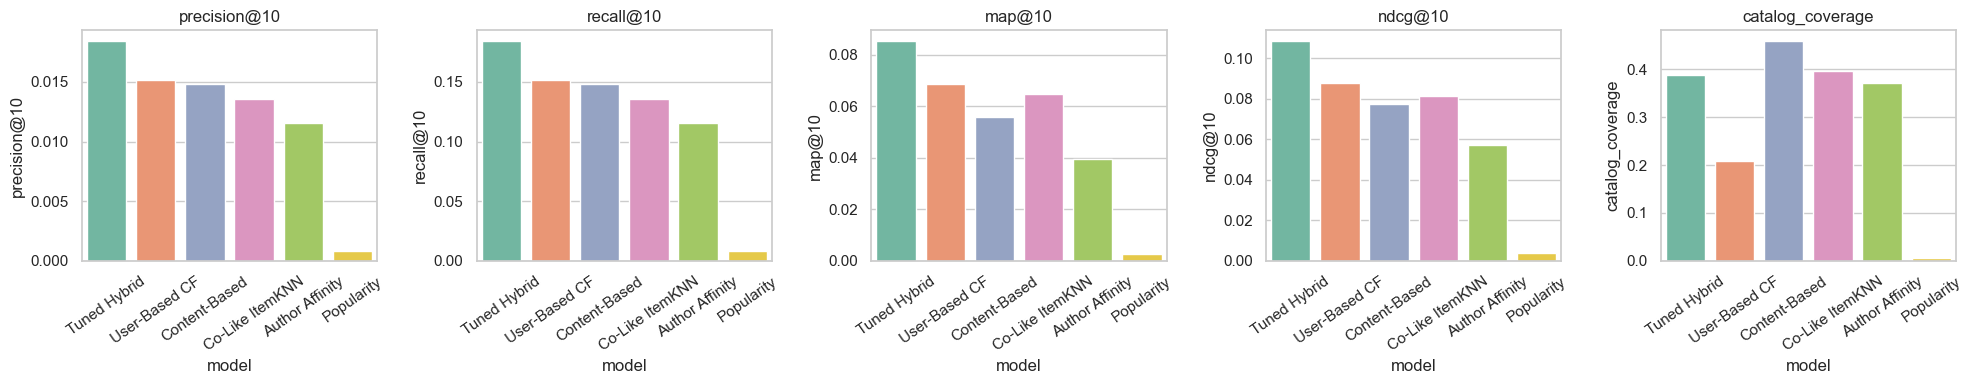

In [19]:
plot_metrics = [f"precision@{TOP_K}", f"recall@{TOP_K}", f"map@{TOP_K}", f"ndcg@{TOP_K}", "catalog_coverage"]

fig, axes = plt.subplots(1, len(plot_metrics), figsize=(20, 4))
for ax, metric in zip(axes, plot_metrics):
    sns.barplot(data=test_summary, x="model", y=metric, ax=ax, palette="Set2")
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

## 9. Contoh Rekomendasi

Bagian ini menampilkan contoh rekomendasi Top-10 dari model hybrid terbaik untuk salah satu pengguna pada evaluation sample.

In [20]:
example_user = int(eval_users[0])
hidden_test_book = test_events[test_events["User-ID"].eq(example_user)][["book_id", "rating"]]

print("Example user:", example_user)
print("Hidden test item:")
display(attach_catalog(hidden_test_book))

recommended_ids = recommend_weighted(example_user, best_weights, n=10)
recommendations = pd.DataFrame({"book_id": recommended_ids})
display(attach_catalog(recommendations)[["Book_Title", "Book_Author", "Publisher", "n_isbn"]])

Example user: 262902
Hidden test item:


,book_id,rating,Book_Title,Book_Author,Publisher,title_key,author_key,publisher_key,n_isbn
0,498,8,The Diary of Ellen Rimbauer: My Life at Rose Red,Joyce Reardon,Hyperion,the diary of ellen rimbauer my life at rose red,joyce reardon,hyperion,1


,Book_Title,Book_Author,Publisher,n_isbn
0,The Secret Life of Bees,Sue Monk Kidd,Penguin Books,6
1,The Red Tent (Bestselling Backlist),Anita Diamant,Picador USA,1
2,Divine Secrets of the Ya-Ya Sisterhood : A Novel,Rebecca Wells,HarperCollins,4
3,Girl with a Pearl Earring,Tracy Chevalier,Plume Books,4
4,Angelas Ashes: A Memoir,Frank McCourt,Scribner,1
5,"Tuesdays with Morrie: An Old Man, a Young Man, and Life's Greatest Lesson",MITCH ALBOM,Doubleday,3
6,ANGELA'S ASHES,Frank McCourt,Scribner,2
7,A Widow for One Year,JOHN IRVING,Ballantine Books,4
8,Fried Green Tomatoes at the Whistle Stop Cafe,Fannie Flagg,McGraw-Hill,5
9,House of Sand and Fog,Andre Dubus III,Vintage Books,2


## 10. Kesimpulan

Model terbaik adalah **Tuned Hybrid**, yaitu gabungan beberapa sinyal rekomendasi dengan bobot yang dipilih dari validation set. Pendekatan hybrid memberikan performa Top-10 terbaik pada test set karena mampu menggabungkan informasi metadata buku, pola kemiripan item, pola kemiripan pengguna, kecenderungan terhadap penulis, dan popularitas buku.

Secara umum, hasil evaluasi menunjukkan bahwa sistem sudah mampu menangkap sebagian pola preferensi pengguna pada dataset yang sparse. Namun, performa masih dipengaruhi oleh keterbatasan dataset, seperti metadata yang terbatas, tidak adanya genre atau sinopsis, serta jumlah interaksi eksplisit yang relatif sparse.

Pengembangan berikutnya yang dapat dilakukan:

1. Menambahkan metadata eksternal seperti genre, sinopsis, atau tag buku.
2. Memanfaatkan rating `0` menggunakan model khusus implicit feedback.
3. Menguji variasi threshold warm-start dan jumlah neighbor.
4. Mengevaluasi performa pada `Top-20` atau `Top-50` jika skenario produk mengizinkan daftar rekomendasi yang lebih panjang.